# SVM (SGDClassifier) — CIC-IDS 2018 | Wrapper Method (RFE)

**Dataset:** CIC-IDS 2018 (balanced parquet)  
**Cross-evaluation:** CIC-IDS 2017 (natural distribution)  
**Feature Selection:** Wrapper method — Recursive Feature Elimination (RFE)  
**Pipeline:** Load data → Group labels → Clean → Encode → Split → Scale → RFE sweep → Rank features → Evaluate → Cross-dataset (Method 1) → Combined training (Method 3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/cic2018_balanced_dataset_standardized.parquet"
raw_data = pd.read_parquet(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,Protocol,Timestamp,Dst Port,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6.0,14/02/2018 08:53:42,60556.0,157.0,2.0,0.0,0.0,0.0,0.0,0.0,...,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
1,6.0,14/02/2018 10:38:48,80.0,53993792.0,2.0,0.0,0.0,0.0,0.0,0.0,...,20.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
2,6.0,14/02/2018 09:38:17,443.0,61113950.0,16.0,14.0,1578.0,2749.0,538.0,0.0,...,20.0,83368.664062,175935.75,442496.0,11484.0,9992150.0,33221.078125,10012729.0,9924726.0,Benign
3,17.0,14/02/2018 11:19:03,53.0,79651.0,1.0,1.0,35.0,51.0,35.0,35.0,...,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
4,17.0,14/02/2018 09:19:31,53.0,12230.0,1.0,1.0,55.0,83.0,55.0,55.0,...,8.0,0.000000,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,Benign


## 1. Load Dataset

Loads the CIC-IDS 2018 balanced dataset from a Parquet file. The dataset contains network flow records labeled with attack categories.

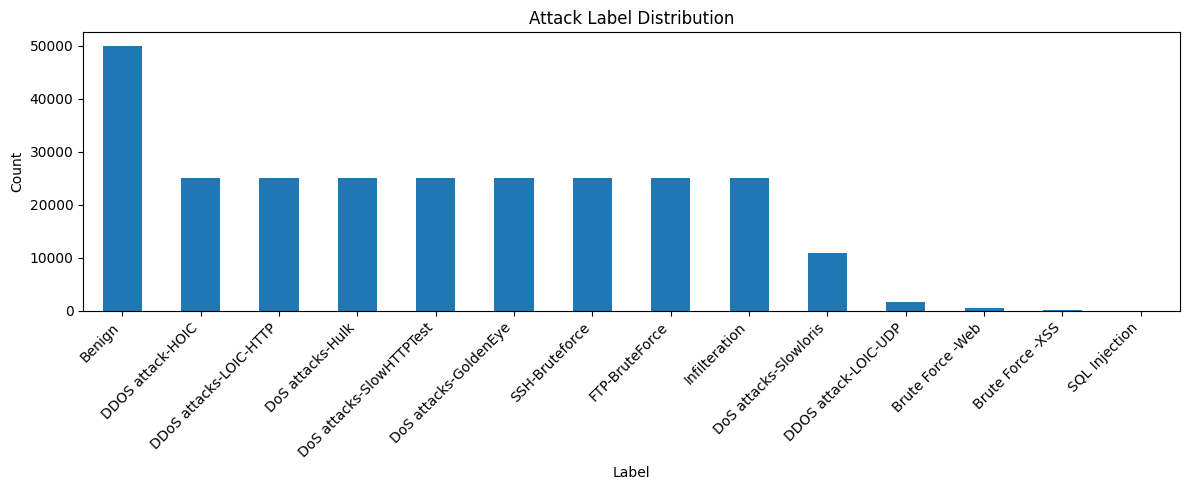

In [2]:
# Label distribution
label_counts = df['Label'].value_counts()

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## 2. Label Distribution

Displays a bar chart of raw attack label counts. This is the un-grouped distribution before any label consolidation.

In [3]:
# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',

    # DoS / DDoS
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-Slowhttptest': 'DoS',
    
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDoS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',

    # Brute Force
    'FTP-BruteForce': 'BruteForce',
    'SSH-Bruteforce': 'BruteForce',
    
    'Brute Force -Web': 'BruteForce',
    'Brute Force -XSS': 'BruteForce',

    'Infilteration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  DoS                      60,990  (25.75%)
  BruteForce               50,841  (21.47%)
  DDoS                     50,000  (21.11%)
  BENIGN                   49,999  (21.11%)
  Infiltration             25,000  (10.56%)


## 3. Group Attack Labels

Maps granular attack sub-types (e.g., DoS Hulk, DoS GoldenEye) into broader categories (DoS, DDoS, BruteForce, Infiltration). Rows with unmapped labels are dropped.

In [4]:
# Check missing / infinity values
numeric_cols = df.select_dtypes(include=[np.number]).columns
missing = df.isnull().sum()
inf_counts = {col: np.isinf(df[col]).sum() for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("Missing:", missing[missing > 0].to_dict() or "None")
print("Infinity:", inf_counts or "None")


Missing: {'Flow Byts/s': 386}
Infinity: {'Flow Byts/s': np.int64(215), 'Flow Pkts/s': np.int64(601)}


## 4. Check Missing and Infinity Values

Scans all numeric columns for NaN and ±inf values so that data quality issues can be identified before any imputation step.

In [5]:
# Handle inf → NaN → median fill
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df_processed.select_dtypes(include=[np.number]).columns:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"Shape: {df_processed.shape}  |  NaN remaining: {df_processed.isnull().sum().sum()}")


Shape: (236830, 81)  |  NaN remaining: 0


/tmp/ipykernel_76936/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_76936/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

## 5. Handle Infinity and Missing Values

Replaces ±inf with NaN, then fills each remaining NaN with the column median. This ensures no infinite or missing values are passed to the model.

In [6]:
# Drop metadata columns
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns if any(k in c.lower() for k in keywords)]
df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Shape: {df_processed.shape}")


Shape: (236830, 79)


## 6. Drop Identifier and Metadata Columns

Removes non-feature columns such as Flow ID, IP addresses, ports, and timestamps. These identifiers carry no generalizable signal for intrusion detection.

In [10]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

print(dict(zip(le.classes_, range(len(le.classes_)))))


{'BENIGN': 0, 'BruteForce': 1, 'DDoS': 2, 'DoS': 3, 'Infiltration': 4}


## 7. Label Encoding

Converts string class labels to integer indices using `LabelEncoder`. The fitted encoder is saved to `label_encoder.pkl1` for later reuse during cross-dataset evaluation.

In [11]:
# Train / test split (stratified 80/20)
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (123901, 35)  |  Test: (30976, 35)


## 8. Train / Test Split

Splits the dataset into 80% training and 20% test sets using stratified sampling to preserve class proportions in both splits.

In [12]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

with open('scaler.pkl1', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")


Train: (123901, 35)  |  Test: (30976, 35)


## 9. Feature Scaling (StandardScaler)

Standardizes all features to zero mean and unit variance. Required by the SGDClassifier (linear SVM). The scaler is fitted on the training set only and saved for inference.

In [ ]:

# RFE — sweep k
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

sgd_baseline = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                               eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
sgd_baseline.fit(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, sgd_baseline.predict(X_test_scaled))

base_estimator = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                                eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
k_values = [k for k in [10, 20, 30, 40, 50, 60, 70] if k < X_train_scaled.shape[1]]
rfe_results = {}

for k in k_values:
    rfe = RFE(estimator=base_estimator, n_features_to_select=k, step=140)
    rfe.fit(X_train_scaled, y_train)
    selected_feats = X_train_scaled.columns[rfe.support_].tolist()
    # Evaluate using the same final-model hyperparams to avoid discrepancy
    sgd_tmp = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                             eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
    sgd_tmp.fit(X_train_scaled[selected_feats], y_train)
    rfe_results[k] = {'accuracy': accuracy_score(y_test, sgd_tmp.predict(X_test_scaled[selected_feats])), 'support': rfe.support_}

best_k = max(rfe_results, key=lambda k: rfe_results[k]['accuracy'])
print(f"Baseline: {test_acc*100:.2f}%  |  Best k={best_k}: {rfe_results[best_k]['accuracy']*100:.2f}%")


Baseline: 92.00%  |  Best k=30: 91.94%


## 10. RFE Feature Selection — Sweep k

Trains a baseline SGDClassifier on all features to establish a reference accuracy. Then runs RFE for each value of k (10 to 70 features) to find the k that maximises test accuracy.

- **Baseline:** model trained on all features (no selection)
- **RFE sweep:** for each k, RFE recursively eliminates the weakest features until k remain, then evaluates accuracy on the test set
- **Best k:** the value of k with the highest accuracy is selected for the final model

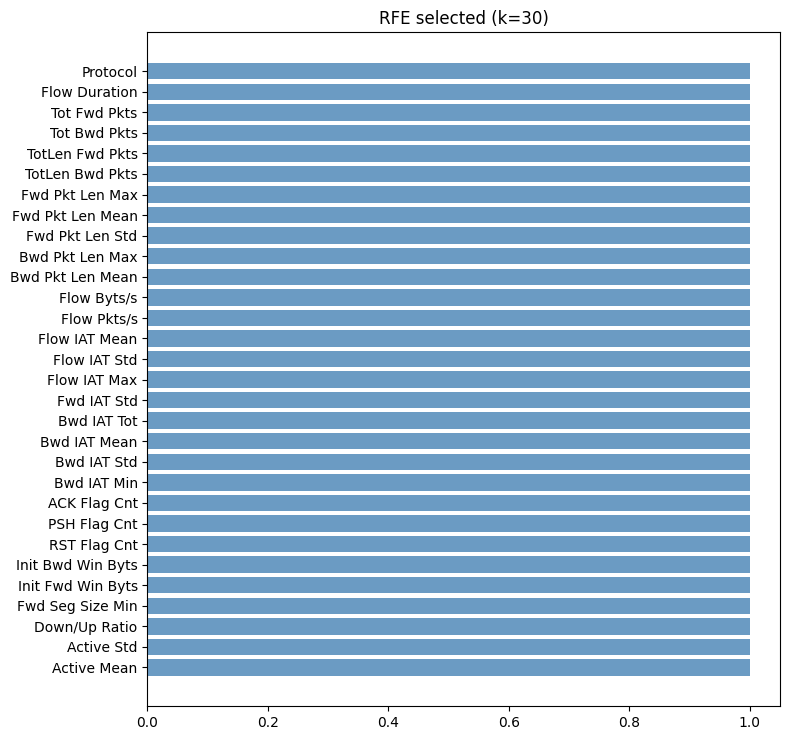

In [ ]:

# Feature ranking (RFE best_k) — importance via mean |coef_| across classes
best_rfe = RFE(estimator=SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
               eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42),
               n_features_to_select=best_k, step=140)
best_rfe.fit(X_train_scaled, y_train)

rfe_features = X_train_scaled.columns[best_rfe.support_].tolist()
importance = np.abs(best_rfe.estimator_.coef_).mean(axis=0)

selected_df = pd.DataFrame({'Feature': rfe_features, 'Importance': importance}) \
                .sort_values('Importance', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(4, best_k * 0.25)))
ax.barh(selected_df['Feature'], selected_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title(f'RFE selected (k={best_k})'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Reuse best_rfe for cross-dataset validation (no re-training) ──────────────
import pickle

sgd_rfe = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                         eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
sgd_rfe.fit(X_train_scaled[rfe_features], y_train)

rfe_sorted = pd.Series(np.abs(best_rfe.estimator_.coef_).mean(axis=0),
                        index=rfe_features).sort_values(ascending=False)

print(f"=== RFE k={best_k} Features (by |coef| importance) ===")
for i, (feat, imp) in enumerate(rfe_sorted.items(), 1):
    print(f"  {i:2d}. {feat:<45} importance={imp:.4f}")

with open('sgd_rfe20_model.pkl', 'wb') as f: pickle.dump(sgd_rfe, f)
with open('rfe20_selected_features.pkl', 'wb') as f: pickle.dump(rfe_features, f)


## 11. RFE Feature Ranking and Final Model

Re-fits RFE with the best k to obtain stable feature rankings. Feature importance is derived from the mean absolute coefficient value (`|coef_|`) across all classes. A horizontal bar chart displays the selected features sorted by importance. The final model and selected feature list are saved to disk.

In [ ]:

# ── Classification report ─────────────────────────────────────────────────────
y_test_pred = sgd_rfe.predict(X_test_scaled[rfe_features])
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


## 12. Classification Report — RFE Model

Prints precision, recall, F1-score, and support for each class. The model uses only the RFE-selected k features evaluated on the held-out test set.

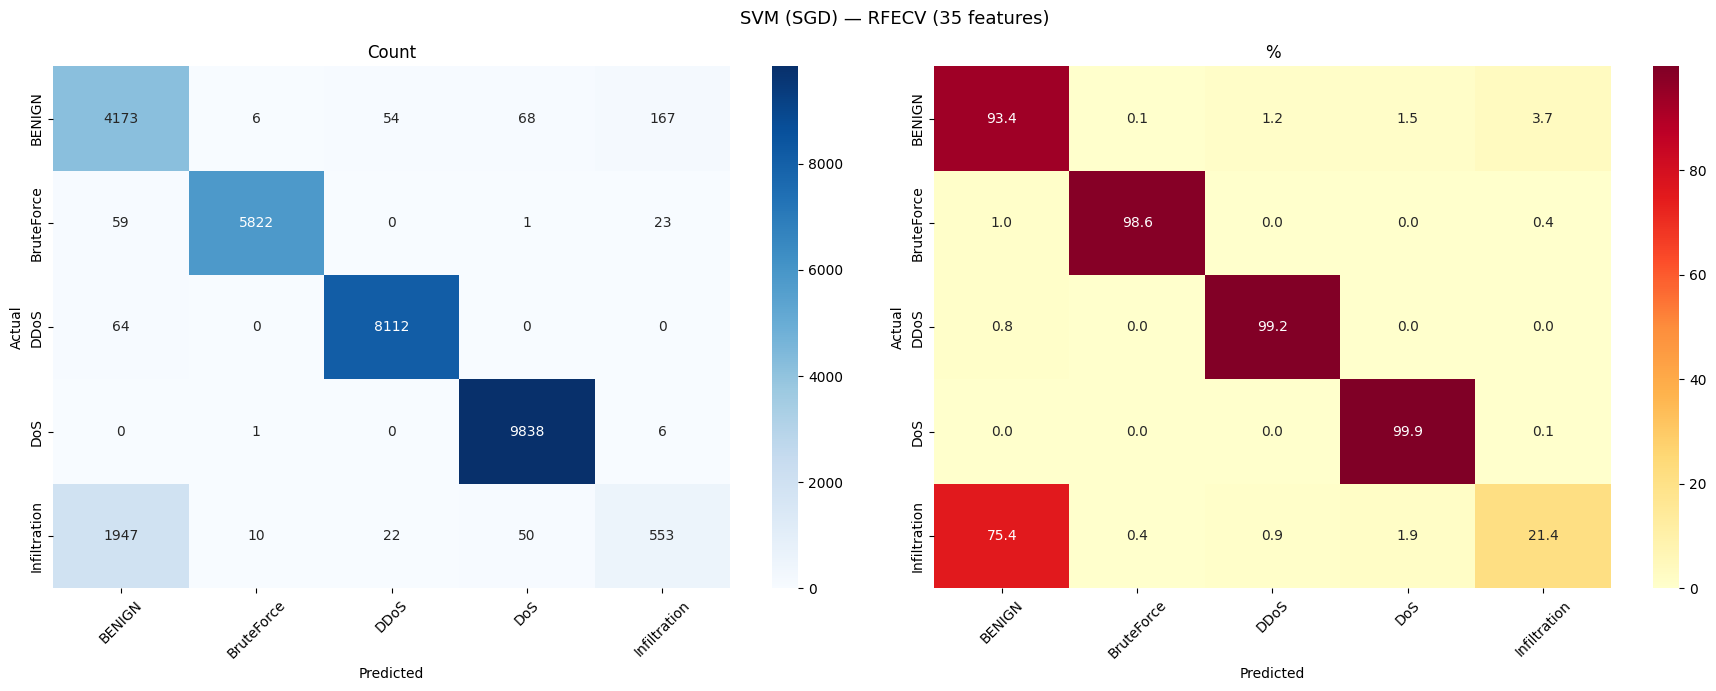

In [ ]:

# Confusion matrix — RFE model
cm = confusion_matrix(y_test, sgd_rfe.predict(X_test_scaled[rfe_features]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Count'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual'); ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('%'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual'); ax2.tick_params(axis='x', rotation=45)

plt.suptitle(f'SVM (SGD) — RFE k={best_k} ({best_k} features)', fontsize=13)
plt.tight_layout(); plt.show()


## 13. Confusion Matrix — RFE Model

Side-by-side heatmaps showing the absolute count (left) and row-normalised percentage (right) for each pair of true vs. predicted classes.

---

## Cross-Dataset Evaluation (CIC-IDS 2017)

The sections below evaluate the model trained on CIC-IDS 2018 against CIC-IDS 2017 data to assess generalisation across datasets.

- **Method 1 — Cross-test:** apply the 2018-trained model directly to the 2017 dataset using only shared RFE features (no retraining)
- **Method 3 — Combined training:** retrain on a combined pool of CIC-2018 and CIC-2017 samples, then evaluate on held-out data from both datasets

In [ ]:
# Load CIC-2017 cross-test dataset (natural distribution)
CIC17_PATH = "../../../../dataset/cicids2017_sample_1M_natural_standardized.csv"
df17_raw = pd.read_csv(CIC17_PATH)
print(f"Shape: {df17_raw.shape}")
print(df17_raw['Label'].value_counts())


Shape: (864031, 79)


Label
BENIGN                        640639
DoS Hulk                      130108
DDoS                           72103
DoS GoldenEye                   5711
FTP-Patator                     4456
SSH-Patator                     3400
DoS slowloris                   3275
DoS Slowhttptest                3058
Web Attack � Brute Force         868
Web Attack � XSS                 361
Infiltration                      36
Heartbleed                        10
Web Attack � Sql Injection         6
Name: count, dtype: int64

## 14. Load CIC-IDS 2017

Loads the CIC-IDS 2017 dataset (1 M rows, natural class distribution) from CSV. The raw label distribution is printed before any grouping.

In [20]:
attack_group_mapping_17 = {
    # # BENIGN
    'BENIGN': 'BENIGN',

    # DoS / DDoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    
    'DDoS': 'DDoS',

    # Brute Force
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    
    'Web Attack � XSS': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',

    'Heartbleed': 'Infiltration',
    'Infiltration': 'Infiltration',
}

df17 = df17_raw.copy()
df17['Label'] = df17['Label'].map(attack_group_mapping_17)
df17.dropna(subset=['Label'], inplace=True)

for g, cnt in df17['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df17)*100:.2f}%)")


  BENIGN                  640,639  (74.43%)
  DoS                     138,877  (16.13%)
  DDoS                     72,103  (8.38%)
  BruteForce                9,085  (1.06%)
  Infiltration                 46  (0.01%)


## 15. Group CIC-IDS 2017 Attack Labels

Applies the same label grouping strategy used for CIC-IDS 2018 so that both datasets share a common set of class names for cross-dataset comparison.

In [21]:
# Preprocess 2017 (same pipeline as 2018)
df17_proc = df17.copy()
df17_proc.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df17_proc.select_dtypes(include=[np.number]).columns:
    if df17_proc[col].isnull().sum() > 0:
        df17_proc[col].fillna(df17_proc[col].median(), inplace=True)

keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop_17 = [c for c in df17_proc.columns if any(k in c.lower() for k in keywords)]
df17_proc.drop(columns=cols_to_drop_17, inplace=True, errors='ignore')
print(f"Shape: {df17_proc.shape}  |  NaN: {df17_proc.isnull().sum().sum()}")


/tmp/ipykernel_76936/2689547596.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df17_proc[col].fillna(df17_proc[col].median(), inplace=True)
/tmp/ipykernel_76936/2689547596.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Shape: (860750, 78)  |  NaN: 0


## 16. Preprocess CIC-IDS 2017

Applies the same cleaning pipeline to the 2017 data: replace ±inf → NaN, fill with median, and drop identifier columns. This ensures feature compatibility with the 2018-trained model.

## 17. Method 1 — Cross-Test (shared RFE features, no retraining)

Evaluates the 2018-trained SGDClassifier directly on CIC-IDS 2017. Only features present in both datasets are used. A sub-scaler is re-fitted on the raw training shared features to prevent data leakage. Accuracy on CIC-2018 and CIC-2017 is compared to quantify the performance drop due to domain shift.

In [ ]:

# Method 1: Cross-test — RFE shared features (no zero-fill)
shared_features = [f for f in rfe_features if f in df17_proc.columns]
missing_in_17 = [f for f in rfe_features if f not in df17_proc.columns]

print(f"RFE k={best_k}: {len(rfe_features)} features  |  Shared with CIC-2017: {len(shared_features)}  |  Missing: {len(missing_in_17)}")
if missing_in_17:
    print(f"  Missing features: {missing_in_17}")

X17 = df17_proc[shared_features]
y17_labels = df17_proc['Label']

known_classes = set(le.classes_)
mask_known = y17_labels.isin(known_classes)
X17 = X17[mask_known]
y17_labels = y17_labels[mask_known]
y17 = le.transform(y17_labels)

scaler_sub = StandardScaler()
X_train_sub_s = scaler_sub.fit_transform(X_train[shared_features])
X_test_sub_s  = scaler_sub.transform(X_test[shared_features])
X17_sub_s     = scaler_sub.transform(X17)

SGD_Shared = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                            eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
SGD_Shared.fit(X_train_sub_s, y_train)
y17_pred = SGD_Shared.predict(X17_sub_s)
acc_src  = accuracy_score(y_test, SGD_Shared.predict(X_test_sub_s))

acc17 = accuracy_score(y17, y17_pred)
print(f"\nCIC-2018 (source): {acc_src*100:.2f}%")
print(f"CIC-2017 (target): {acc17*100:.2f}%  |  Drop: {(acc_src-acc17)*100:.2f}%")
print()
present_indices = sorted(set(y17))
print(classification_report(y17, y17_pred, labels=present_indices,
                             target_names=le.inverse_transform(present_indices),
                             digits=4, zero_division=0))


CIC-2018 (source): 92.02%
CIC-2017 (target): 49.60%  |  Drop: 42.42%

              precision    recall  f1-score   support

      BENIGN     0.8333    0.4456    0.5807    640639
  BruteForce     0.0351    0.1987    0.0596      9085
        DDoS     0.7825    0.3873    0.5181     72103
         DoS     0.3286    0.8040    0.4665    138877
Infiltration     0.0002    0.3261    0.0003        46

    accuracy                         0.4960    860750
   macro avg     0.3959    0.4323    0.3251    860750
weighted avg     0.7392    0.4960    0.5515    860750



## 18. Method 3 — Combined Training (CIC-2018 + CIC-2017)

Retrains the SGDClassifier on a merged pool of CIC-2018 and CIC-2017 samples using only the shared RFE-selected features. A separate scaler is fit on the combined training set. The combined test set is split by source to report per-dataset accuracy.

In [ ]:

# Method 3: Retrain on combined CIC-2018 + CIC-2017 (RFE k=20 shared features)
from sklearn.preprocessing import LabelEncoder

X18_shared = df_processed.drop(['Label', 'Label_Encoded'], axis=1)[shared_features]
y18_labels = df_processed['Label']
X17_shared = df17_proc[shared_features]
y17_all_labels = df17_proc['Label']

common_classes = set(y18_labels.unique()) & set(y17_all_labels.unique())
mask18 = y18_labels.isin(common_classes)
mask17 = y17_all_labels.isin(common_classes)

X_combined = pd.concat([X18_shared[mask18], X17_shared[mask17]], ignore_index=True)
y_combined_labels = pd.concat([y18_labels[mask18], y17_all_labels[mask17]], ignore_index=True)
source = pd.Series(['CIC18'] * mask18.sum() + ['CIC17'] * mask17.sum())

le_combined = LabelEncoder()
y_combined = le_combined.fit_transform(y_combined_labels)

X_comb_train, X_comb_test, y_comb_train, y_comb_test, src_train, src_test = \
    train_test_split(X_combined, y_combined, source, test_size=0.2, stratify=y_combined, random_state=42)

scaler_comb = StandardScaler()
X_comb_train_s = scaler_comb.fit_transform(X_comb_train)
X_comb_test_s  = scaler_comb.transform(X_comb_test)

SGD_combine = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001,
                             eta0=0.1, learning_rate='adaptive', max_iter=1000, random_state=42)
SGD_combine.fit(X_comb_train_s, y_comb_train)

mask_18_test = src_test == 'CIC18'
mask_17_test = src_test == 'CIC17'
print(f"Overall : {accuracy_score(y_comb_test, SGD_combine.predict(X_comb_test_s))*100:.2f}%")
print(f"CIC-2018: {accuracy_score(y_comb_test[mask_18_test.values], SGD_combine.predict(X_comb_test_s[mask_18_test.values]))*100:.2f}%")
print(f"CIC-2017: {accuracy_score(y_comb_test[mask_17_test.values], SGD_combine.predict(X_comb_test_s[mask_17_test.values]))*100:.2f}%")


Overall : 87.24%
CIC-2018: 58.27%
CIC-2017: 92.43%


## 19. Classification Report + Confusion Matrix — Combined Model

Evaluates the combined model on the held-out pooled test set. Per-class precision, recall, and F1 are reported, followed by dual heatmaps (count and row-normalised %) showing which classes transfer well between CIC-2018 and CIC-2017.

              precision    recall  f1-score   support

      BENIGN     0.8693    0.9573    0.9112    132596
  BruteForce     0.8722    0.8537    0.8628      7722
        DDoS     0.9107    0.9409    0.9256     22597
         DoS     0.8584    0.5948    0.7027     37620
Infiltration     0.3241    0.0181    0.0344      2591

    accuracy                         0.8724    203126
   macro avg     0.7670    0.6729    0.6873    203126
weighted avg     0.8650    0.8724    0.8611    203126



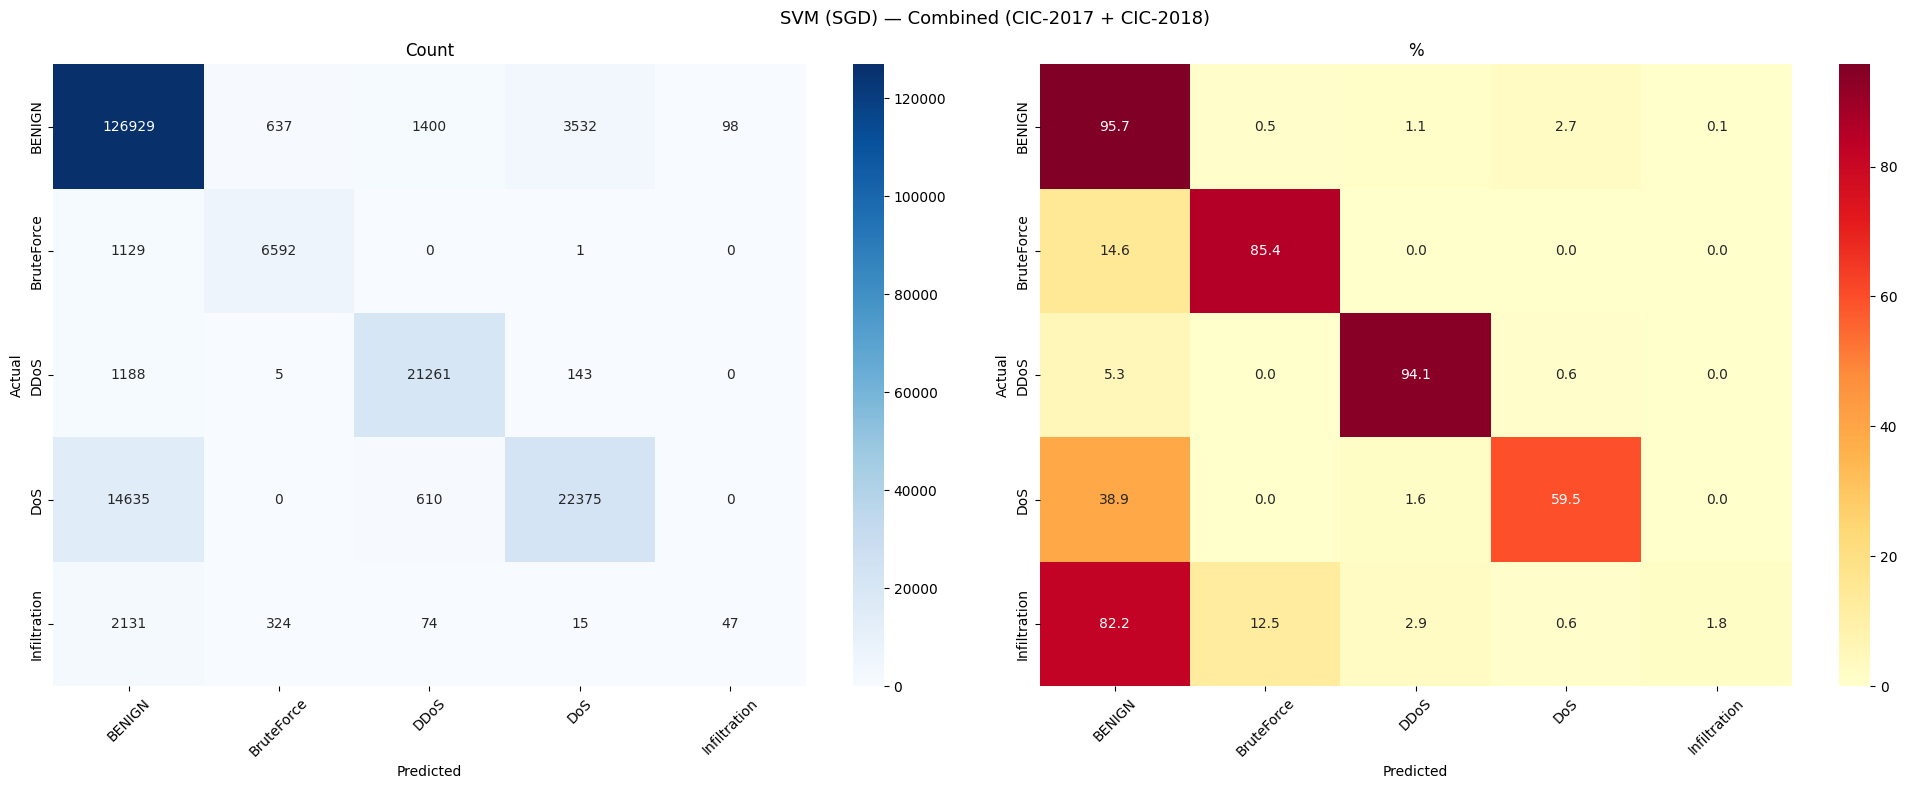

In [25]:
# Classification report + confusion matrix — combined model
print(classification_report(y_comb_test, SGD_combine.predict(X_comb_test_s),
                             target_names=le_combined.classes_, digits=4, zero_division=0))

cm_combined = confusion_matrix(y_comb_test, SGD_combine.predict(X_comb_test_s))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax1)
ax1.set_title('Count'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm_combined.astype(float) / cm_combined.sum(axis=1, keepdims=True) * 100,
            annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax2)
ax2.set_title('%'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('SVM (SGD) — Combined (CIC-2017 + CIC-2018)', fontsize=13)
plt.tight_layout(); plt.show()
